In [1]:
from skimage.io import imread
path_=r"D:\images\tnia-python-images\deconvolution\bead"
path_=r"/home/bnorthan/images/tnia-python-images/bead/"

bead=imread(path_+"/Bead.tif")
psf=imread(path_+"/PSF-Bead.tif")

print(bead.shape)
print(psf.shape)
    
xy_spacing = 0.0645
z_spacing=.16

(256, 256, 256)
(256, 256, 256)


In [2]:
from tnia.plotting.projections import show_xy_zy_slice_center
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

# Find bead center via thresholding + regionprops centroid
thresh = threshold_otsu(bead)
labeled = label(bead > thresh)
props = regionprops(labeled)
largest = max(props, key=lambda p: p.area)
cz, cy, cx = [int(round(c)) for c in largest.centroid]
print(f"Bead center: z={cz}, y={cy}, x={cx}")

# Fixed XY crop diameter, variable Z crops
xy_half = 50  # diameter 100 -> half = 50
z_halfs = [32, 8, 4, 2, 1, 0]

# Crop helper: crop size = 2*half + 1 (center + both sides)
def crop_bead(img, cz, cy, cx, zh, xyh):
    z0 = max(cz - zh, 0);   z1 = min(cz + zh + 1, img.shape[0])
    y0 = max(cy - xyh, 0);  y1 = min(cy + xyh + 1, img.shape[1])
    x0 = max(cx - xyh, 0);  x1 = min(cx + xyh + 1, img.shape[2])
    return img[z0:z1, y0:y1, x0:x1]

# Render figure to RGBA array and close it
def fig_to_array(fig):
    fig.canvas.draw()
    buf = np.array(fig.canvas.renderer.buffer_rgba())
    plt.close(fig)
    return buf

# One-liner: crop, show, and return rendered array
def show_crop(img, cz, cy, cx, zh, xyh, title=''):
    cropped = crop_bead(img, cz, cy, cx, zh, xyh)
    fig = show_xy_zy_slice_center(cropped, sz=z_spacing/xy_spacing, figsize=(8, 3))
    fig.suptitle(title or f'z_half={zh}  shape={cropped.shape}', fontsize=12, y=0.98)
    fig.subplots_adjust(top=0.88)
    return fig_to_array(fig), cropped

# Generate crops and collect rendered images
spacer_height = 30
sub_images = []
crops = {}
for zh in z_halfs:
    cropped = crop_bead(bead, cz, cy, cx, zh, xy_half)
    crops[zh] = cropped


Bead center: z=102, y=124, x=128


PSF center: z=128, y=128, x=128


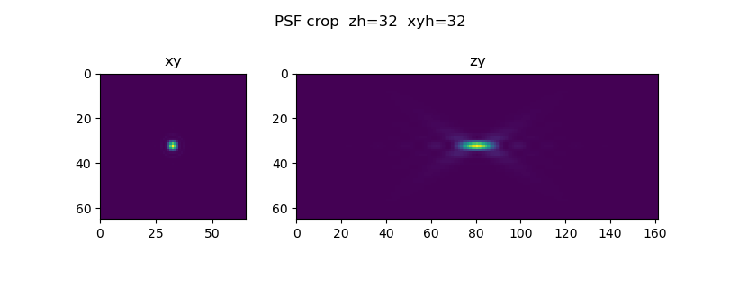

In [3]:
# Crop and show PSF using the same show_crop helper
psf_zh = 32
psf_xy_half = 32

thresh_psf = threshold_otsu(psf)
labeled_psf = label(psf > thresh_psf)
props_psf = regionprops(labeled_psf)
largest_psf = max(props_psf, key=lambda p: p.area)
pcz, pcy, pcx = [int(round(c)) for c in largest_psf.centroid]
print(f"PSF center: z={pcz}, y={pcy}, x={pcx}")

psf_img_arr, psf_cropped = show_crop(psf, pcz, pcy, pcx, psf_zh, psf_xy_half, title=f'PSF crop  zh={psf_zh}  xyh={psf_xy_half}')
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.imshow(psf_img_arr)
ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp


0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 

0 10 20 170 180 190 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 

0 10 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 

0 10 20 30 40 50 60 70 80 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
90 100 110 120 130 140 150 160 170 180 190 
Saved to bead_decon_circular.png
Saved to bead_decon_circular.png


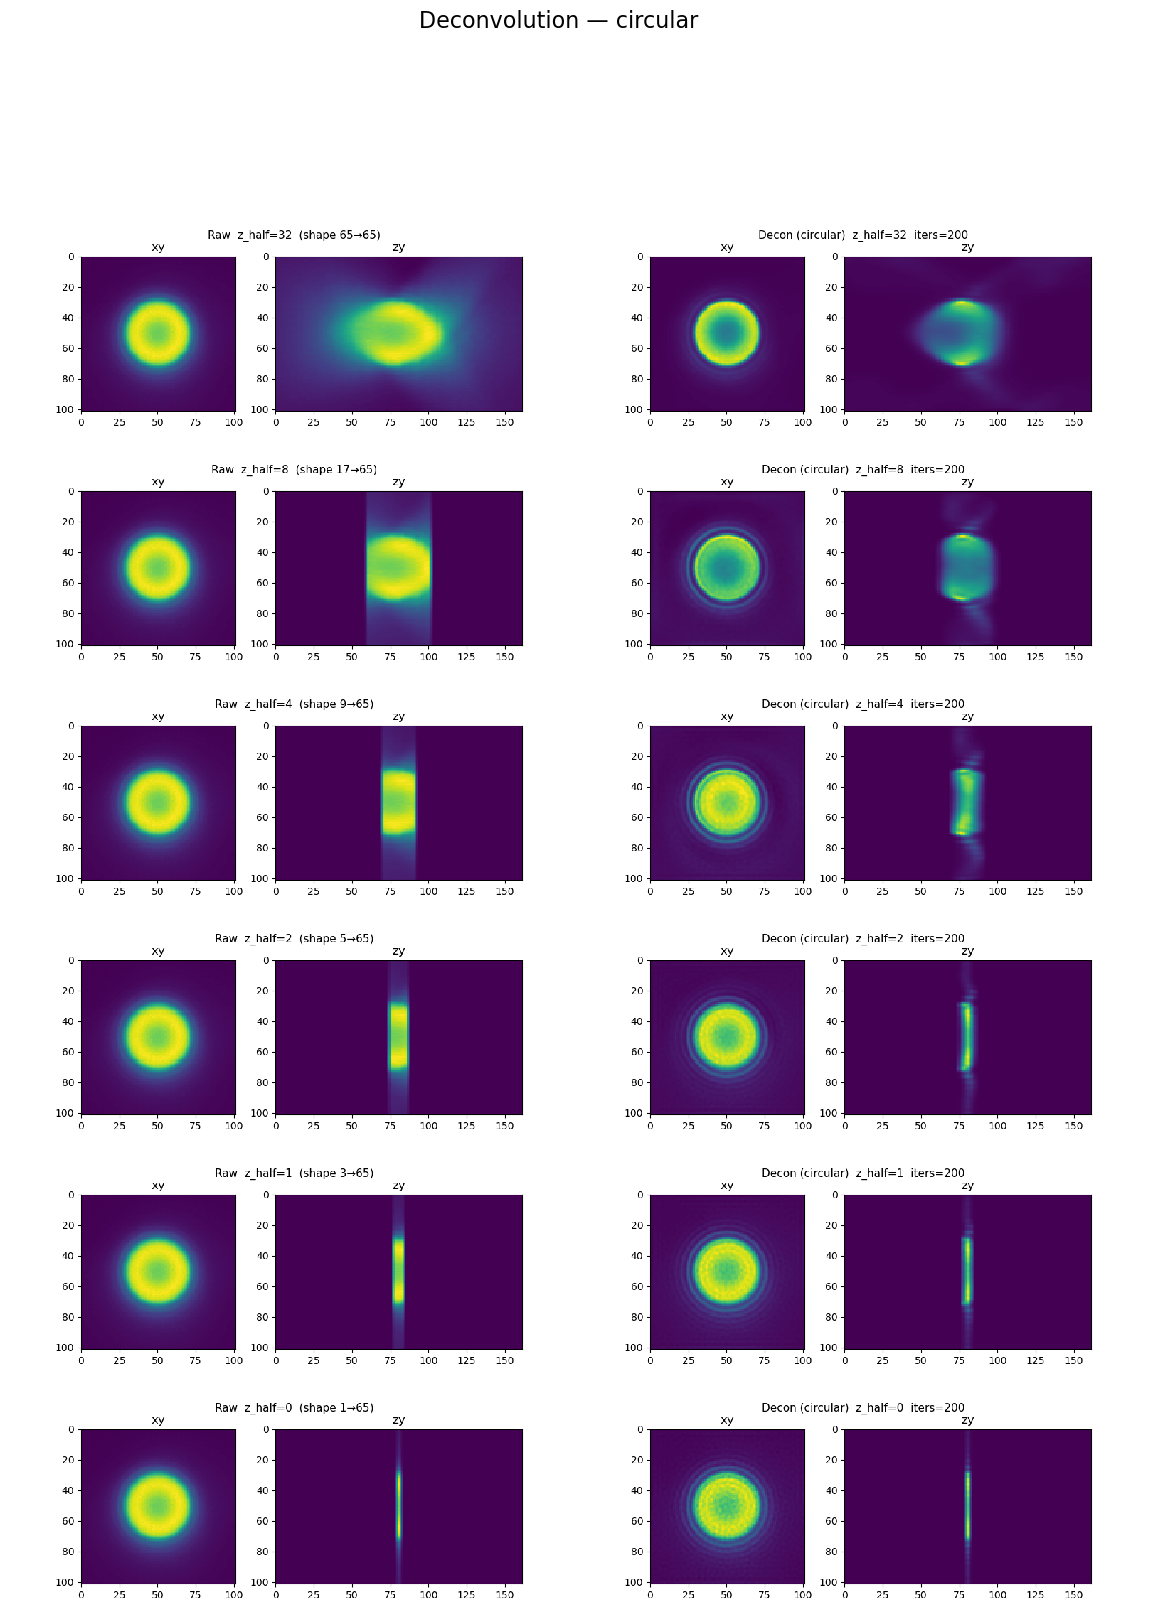


0 10 20 30 10 20 30 40 40 50 60 70 50 60 70 80 80 90 100 110 90 100 110 120 120 130 140 150 130 140 150 160 160 170 180 190 170 180 190 


0 10 20 
0 10 20 30 40 50 60 70 30 40 50 60 70 80 90 100 80 90 100 110 120 130 140 150 110 120 130 140 150 160 170 180 160 170 180 190 
190 

0 10 
0 10 20 30 40 50 60 70 20 30 40 50 60 70 80 90 80 90 100 110 120 130 140 150 100 110 120 130 140 150 160 170 160 170 180 190 
180 190 

0 10 20 30 40 50 60 70 80 90 
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 100 110 120 130 140 150 160 170 180 190 

0 10 20 30 

0 10 20 30 40 50 60 70 80 90 100 110 120 130 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 
140 150 160 170 180 190 

0 10 20 30 40 50 60 70 80 90 
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 100 110 120 130 140 150 160 170 180 190 

Saved to bead_decon_noncirc.png
Saved to bead_decon_noncirc.png


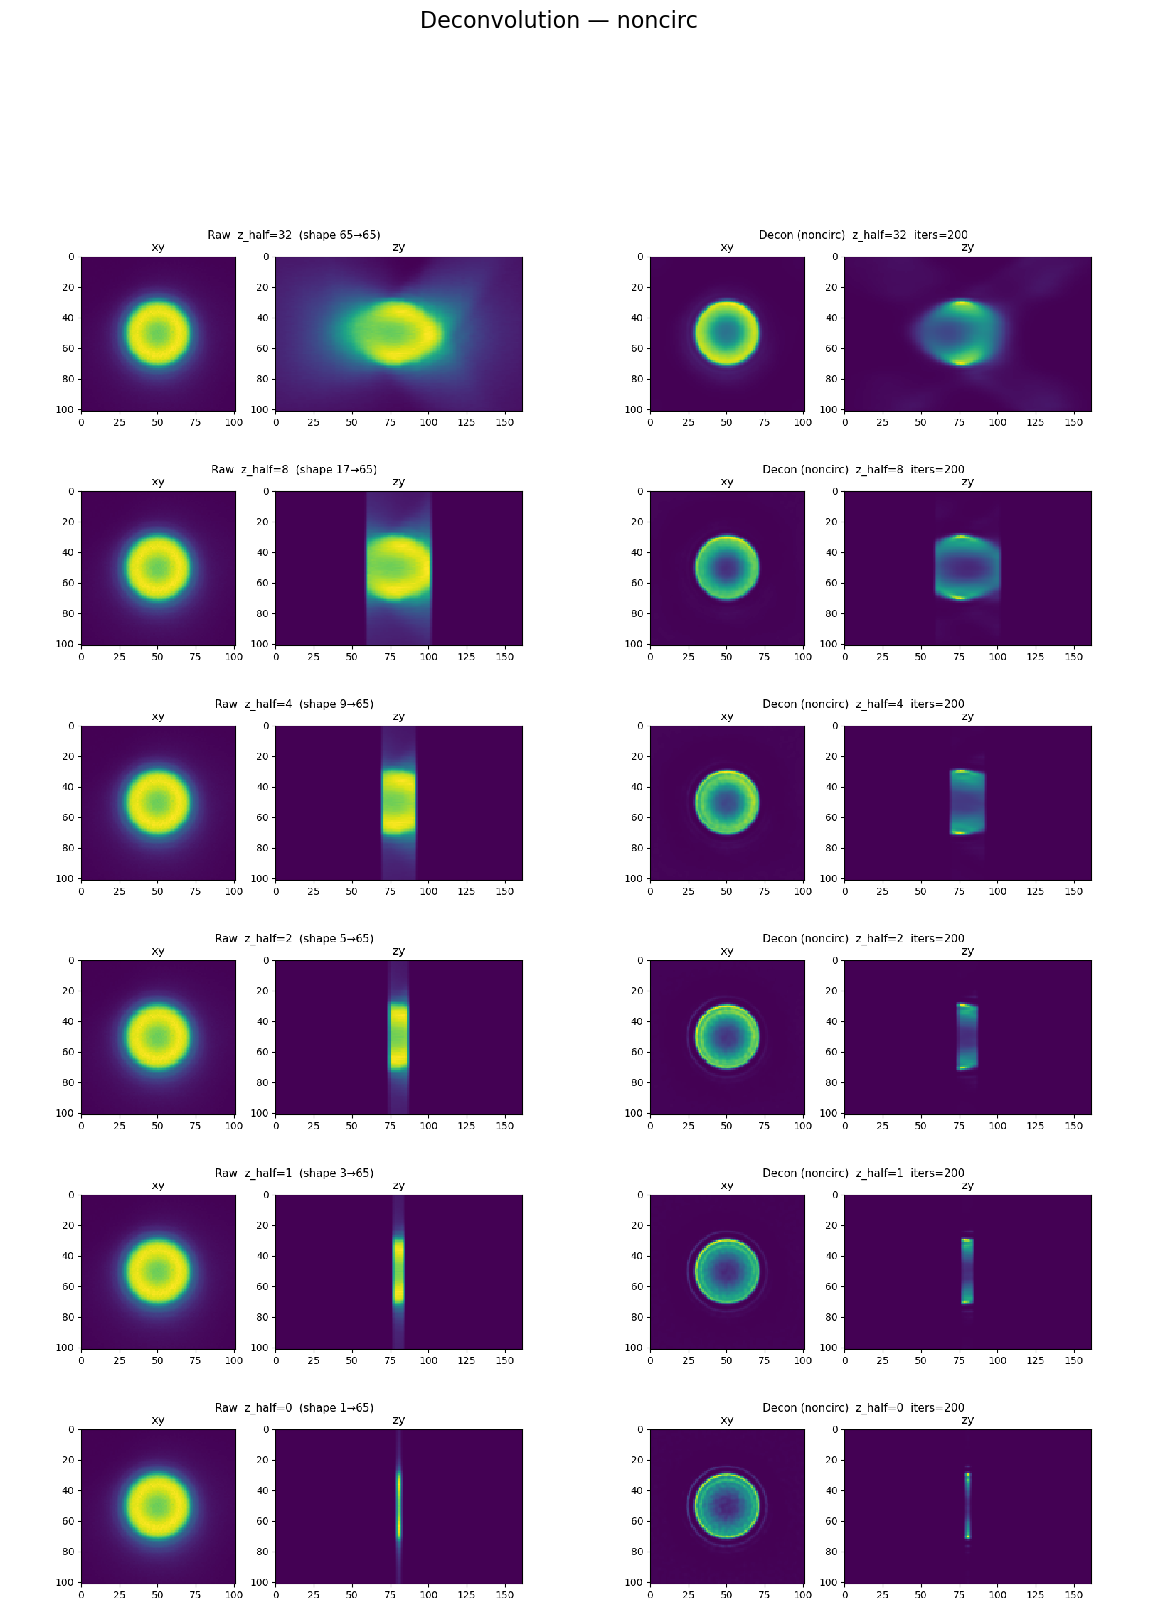

In [8]:
num_iters = 200
sz_ratio = z_spacing / xy_spacing
spacer_height = 30
display_z = 2 * 32 + 1  # uniform z depth for all display volumes

def prep_for_display(vol, display_z):
    """Crop center or zero-pad in z so all volumes have the same z depth (display only)."""
    nz = vol.shape[0]
    if nz > display_z:
        start = (nz - display_z) // 2
        return vol[start:start + display_z]
    elif nz < display_z:
        pad_before = (display_z - nz) // 2
        pad_after = display_z - nz - pad_before
        return np.pad(vol, ((pad_before, pad_after), (0, 0), (0, 0)), mode='constant')
    return vol

psf_norm = psf_cropped.astype(np.float32) / np.sum(psf_cropped)

for noncirc in [False, True]:
    nc_label = 'noncirc' if noncirc else 'circular'
    sub_images = []

    for zh in z_halfs:
        bead_crop = crops[zh].astype(np.float32)
        decon = richardson_lucy_cp(bead_crop, psf_norm, num_iters, noncirc=noncirc)

        bead_disp = prep_for_display(bead_crop, display_z)
        decon_disp = prep_for_display(decon, display_z)

        fig_bead = show_xy_zy_slice_center(bead_disp, sz=sz_ratio, figsize=(8, 3))
        fig_bead.suptitle(f'Raw  z_half={zh}  (shape {bead_crop.shape[0]}→{display_z})', fontsize=11, y=0.98)
        fig_bead.subplots_adjust(top=0.88)
        arr_bead = fig_to_array(fig_bead)

        fig_decon = show_xy_zy_slice_center(decon_disp, sz=sz_ratio, figsize=(8, 3))
        fig_decon.suptitle(f'Decon ({nc_label})  z_half={zh}  iters={num_iters}', fontsize=11, y=0.98)
        fig_decon.subplots_adjust(top=0.88)
        arr_decon = fig_to_array(fig_decon)

        row = np.hstack([arr_bead, arr_decon])
        sub_images.append(row)
        sub_images.append(np.full((spacer_height, row.shape[1], 4), 255, dtype=np.uint8))

    sub_images = sub_images[:-1]
    combined = np.vstack(sub_images)

    save_path = f'bead_decon_{nc_label}.png'
    big_fig, ax = plt.subplots(1, 1, figsize=(16, len(z_halfs) * 3.0))
    big_fig.suptitle(f'Deconvolution — {nc_label}', fontsize=16, y=1.0)
    ax.imshow(combined)
    ax.axis('off')
    big_fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved to {save_path}")
    plt.show()